# Tutorial 3: Integrating SpatialZoomer with an R-based GiottoSuite Workflow

This tutorial demonstrates how **SpatialZoomer** can be integrated into an R-based spatial transcriptomics (ST) analysis pipeline. Specifically, raw data is first processed in **GiottoSuite** (R) for data import, quality control, and optional annotation, and the processed object is then exported in `.h5ad` format. The `.h5ad` file is subsequently loaded in Python as input for SpatialZoomer to perform feature extraction and multi-scale clustering.

This tutorial is intended to provide a practical example of how SpatialZoomer can be incorporated into existing **R/Python hybrid analysis pipelines**.

**Dataset:** Xenium v1 Human Lung Cancer (149,195 cells, 377 genes).  
The **input ST data** in AnnData format can be downloaded from [Google Cloud](https://drive.google.com/file/d/1ITh3qNTEgnyqFh3BLXMvjTQxRsVsZkBC/view?usp=drive_link).
The original data can be downloaded from [Xenium v1 Lung Cancer dataset](https://www.10xgenomics.com/datasets/preview-data-ffpe-human-lung-cancer-with-xenium-multimodal-cell-segmentation-1-standard).  

## Overview

The workflow consists of two parts:

| Step | Environment | Tool | Description |
|------|-------------|------|-------------|
| **Part 1** | R | GiottoSuite | Data import, QC, normalization, dimensionality reduction, clustering, annotation, and export to `.h5ad` |
| **Part 2** | Python | SpatialZoomer | Load `.h5ad`, multi-scale feature extraction, critical scale identification, and multi-scale clustering |

---
## Part 1: Preprocessing in GiottoSuite (R)

The following steps are performed in **R** using GiottoSuite. They are included here as reference code. Please run them in an R environment (e.g., RStudio) before proceeding to Part 2.

### Prerequisites

- R >= 4.1
- [GiottoSuite](https://github.com/giotto-suite/Giotto) installed
- A Giotto-compatible Python environment (for the `giottoToAnnData()` export step)


```r
# Install Giotto Suite if not already installed
if(!"Giotto" %in% installed.packages()) {
  pak::pkg_install("drieslab/Giotto")
}

# Install the Giotto Python environment (only needs to be run once)
genv_exists <- Giotto::checkGiottoEnvironment()
if(!genv_exists){
  Giotto::installGiottoEnvironment()
}
```

### 1.1 Create a Giotto Object from Xenium Output

Set `data_dir` to the directory containing the Xenium output files.

```r
library(Giotto)

data_dir <- "/path/to/XeniumLungCancer/"

xenium_object <- createGiottoXeniumObject(
  data_dir,
  transcript_path = NULL,
  bounds_path = list(cell = "cell", nucleus = "nucleus"),
  gene_panel_json_path = NULL,
  expression_path = NULL,
  cell_metadata_path = NULL,
  feat_type = c("rna", "NegControlProbe", "UnassignedCodeword", "NegControlCodeword"),
  split_keyword = list("NegControlProbe", "UnassignedCodeword", "NegControlCodeword"),
  qv_threshold = 20,
  load_transcripts = TRUE,
  load_expression = FALSE,
  load_cellmeta = FALSE
)
```

### 1.2 Calculate Feature Overlaps and Build Expression Matrix

Assign transcript counts to cells based on polygon boundaries.

```r
# Calculate overlaps of "rna" features with the "cell" polygon boundaries
xenium_object <- calculateOverlapRaster(xenium_object,
    spatial_info = 'cell',
    feat_info = 'rna'
)

# Convert polygon overlaps to an expression matrix
xenium_object <- overlapToMatrix(xenium_object,
    poly_info = 'cell',
    feat_info = 'rna',
    name = 'raw'
)
```

### 1.3 Quality Control, Normalization, and Dimensionality Reduction

```r
# Filter, normalize, compute statistics, and run PCA
xenium_object <- xenium_object |>
    filterGiotto(
        spat_unit = 'cell',
        expression_threshold = 1,
        feat_det_in_min_cells = 3,
        min_det_feats_per_cell = 5
    ) |>
    normalizeGiotto() |>
    addStatistics() |>
    runPCA(feats_to_use = NULL)  # don't select HVFs since there are too few features
```

### 1.4 Clustering and Annotation (Optional)

Perform UMAP, t-SNE, and Leiden clustering. This step is **optional** — annotation labels can be used for downstream interpretation but are not required by SpatialZoomer.

```r
# Dimensionality reduction for visualization
xenium_object <- runtSNE(xenium_object, dimensions_to_use = 1:10)
xenium_object <- runUMAP(xenium_object, dimensions_to_use = 1:10)

# Shared nearest neighbor network and Leiden clustering
xenium_object <- xenium_object |>
    createNearestNetwork(dimensions_to_use = 1:10, k = 10) |>
    doLeidenCluster(resolution = 0.25, n_iterations = 100)

# Visualize clustering results
plotUMAP(xenium_object,
    cell_color = 'leiden_clus',
    show_legend = FALSE,
    point_size = 0.01,
    point_shape = 'no_border'
)

spatPlot2D(xenium_object,
    plot_method = "scattermore",
    cell_color = 'leiden_clus',
    point_size = 1,
    point_shape = 'no_border',
    background_color = 'black'
)
```

### 1.5 Export the Giotto Object to `.h5ad` Format

Use `giottoToAnnData()` to convert the Giotto object to an AnnData-compatible `.h5ad` file. This bridges the R preprocessing results to the Python ecosystem.

> **Note:** Before exporting, we clear the network slots. The `giottoToAnnData()` function requires a Giotto Python environment; see the [GiottoSuite documentation](https://drieslab.github.io/Giotto_website/) for setup details.

```r
# Clear network slots to avoid export issues
xenium_object@nn_network <- list()
xenium_object@spatial_network <- list()

# Export to h5ad
giottoToAnnData(
  gobject = xenium_object,
  spat_unit = NULL,
  feat_type = NULL,
  python_path = NULL,
  env_name = "giotto_env",
  save_directory = "/path/to/output/"  # directory where the .h5ad will be saved
)
```

After running the above code, you will find a file named `cell_rna_converted_gobject.h5ad` (or similar) in the specified output directory.

---
## Part 2: Multi-scale Analysis with SpatialZoomer (Python)

Starting from here, all code is executable in Python. We load the `.h5ad` file exported from GiottoSuite and use SpatialZoomer for multi-scale spatial analysis.

### Expected Input Format

SpatialZoomer expects an **AnnData** object with:
- `adata.X`: the (normalized or raw) expression matrix.
- `adata.obsm['spatial']`: spatial coordinates of cells.

The `.h5ad` file exported by `giottoToAnnData()` should satisfy these requirements. Verify after loading.

### 2.0 Load Packages

In [1]:
import warnings
warnings.filterwarnings("ignore")

import spatialzoomer as sz
import scanpy as sc
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": 'sans-serif',
    "mathtext.fontset": 'stix',
    "font.size": 7,
    'pdf.fonttype': 42,
})

### 2.1 Load the Exported `.h5ad` File

Set the path to the `.h5ad` file exported from GiottoSuite in Part 1.

In [ ]:
runLabel = 'XeniumLungCancer_Giotto'
save_path = './results/' + runLabel + '_SpatialZoomer/'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Load the h5ad file exported from GiottoSuite
ad = sc.read_h5ad("/path/to/cell_rna_converted_gobject.h5ad")
ad

AnnData object with n_obs × n_vars = 158615 × 377
    obs: 'nr_feats', 'perc_feats', 'total_expr', 'area', 'leiden_clus'
    var: 'ensembl', 'type', 'nr_cells', 'perc_cells', 'total_expr', 'mean_expr', 'mean_expr_det', 'highly_variable'
    uns: 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'cell_rna_normalized', 'cell_rna_scaled'

Verify that the AnnData object contains the expected fields:

In [3]:
# Check that spatial coordinates exist
assert 'spatial' in ad.obsm, "Missing spatial coordinates in adata.obsm['spatial']"
print(f"Cells: {ad.n_obs}, Genes: {ad.n_vars}")
print(f"Spatial coordinates shape: {ad.obsm['spatial'].shape}")
print(f"Available obs columns: {list(ad.obs.columns)}")

Cells: 158615, Genes: 377
Spatial coordinates shape: (158615, 2)
Available obs columns: ['nr_feats', 'perc_feats', 'total_expr', 'area', 'leiden_clus']


If Leiden clustering was performed in GiottoSuite, you can visualize the annotation from the R pipeline:

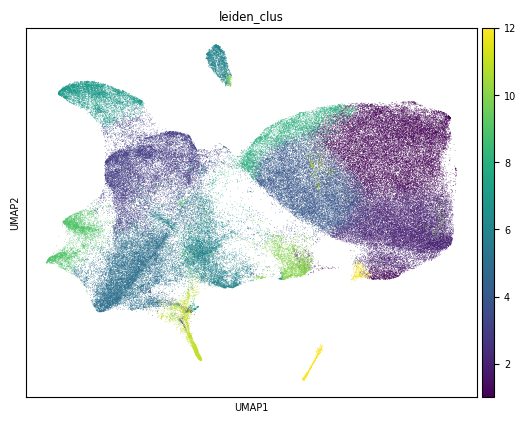

In [4]:
# Optional: visualize Giotto's Leiden clustering if available
if 'leiden_clus' in ad.obs.columns:
    sc.pl.umap(ad, color=['leiden_clus'], wspace=0.4)

### 2.2 Normalization and Feature Extraction

Apply log-normalization and perform NMF-based dimensionality reduction to obtain graph signals. `n_components` specifies the dimensionality of the graph signals.

In [5]:
ad = sz.Preprocess(ad)
ad = sz.performDR(ad, type='NMF', n_components=50)

Time taken to perform NMF: 40.5298 seconds


### 2.3 Multi-scale Feature Extraction via Spectral Graph Signal Processing

Initialize the SpatialZoomer analyzer and perform multi-scale transformation:

- A **spatial neighbor graph** is constructed based on the physical proximity of cells.
- A bank of **heat kernel–based low-pass filters** is applied to extract features across multiple spatial scales.

Parameters:
- `use_rep`: selects graph signals from `adata.obsm`; here we use `"X_nmf"` (NMF-transformed data).
- `n_neighbors`: number of neighbors in the spatial neighbor graph (recommended: 10–20).

In [6]:
sz_analyzer = sz.MultiscaleAnalysis(adata=ad, runLabel=runLabel, save_path=save_path)
sz_analyzer.multiscale_transform(use_rep='X_nmf', n_neighbors=20)

Median similarities:  4.999999999971186
time taken to construct spatial_knn: 0.6872 seconds
Time taken to perform spectral graph filter bank: 106.0125 seconds
Transformed signals saved to ./results/XeniumLungCancer_Giotto_SpatialZoomer//XeniumLungCancer_Giotto_transformed_signals.h5


### 2.4 Identify Critical Scales

SpatialZoomer automatically identifies critical scales using a dynamic programming strategy that partitions the cross-scale similarity map into contiguous diagonal blocks. From each block, the start and center points are selected as critical scales.

- `max_clusters` and `min_clusters` specify the range of possible block numbers.

The optimal number of clusters is: 5
Optimal clusters (start, end): [(0, 20), (21, 24), (25, 31), (32, 51), (52, 57)]
Cluster centers: [1.0, 3.5, 6.0, 13.0, 40]
Typical scales: [0.01, 1.0, 2.5, 3.5, 4.5, 6.0, 8.0, 13.0, 25, 40]
Time taken to perform identification of typical scales: 7.0449 seconds


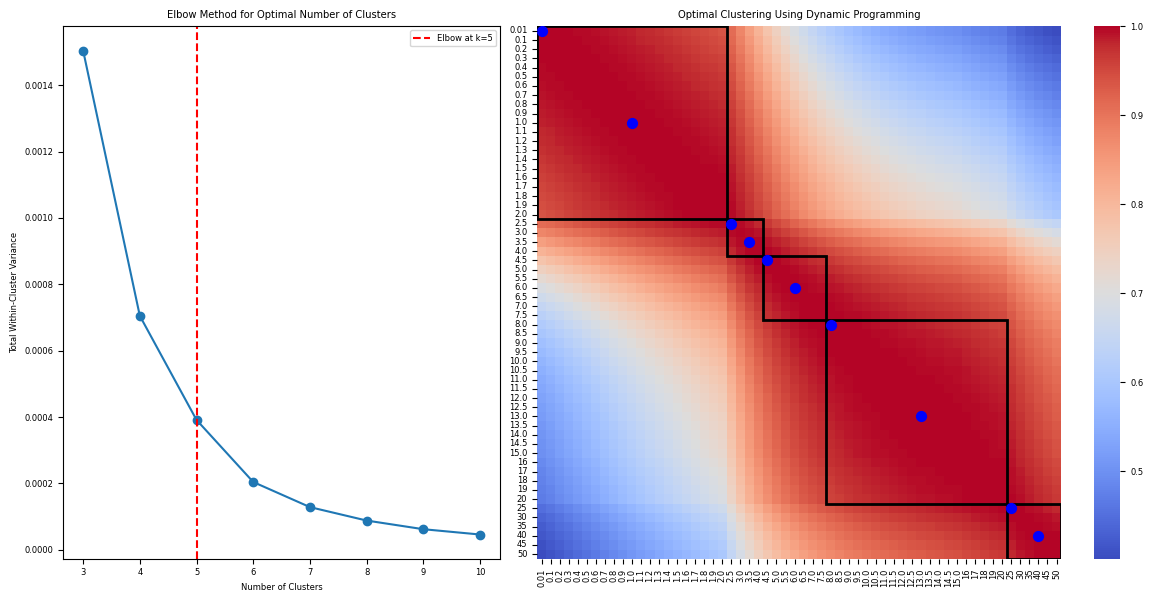

In [7]:
sz_analyzer.identify_typical_scales(max_clusters=10, min_clusters=3)

### 2.5 Multi-scale Clustering

Clustering is performed in two steps:
1. **Mini-Batch K-Means** on the transformed signals to obtain 10,000 metacells.
2. **Leiden algorithm** on the metacells to obtain fine-grained clusters.

**Recommendation:** test multiple resolution values (e.g., 0.2, 0.4, 0.8, 1.0) and select the one that best matches biological expectations.

Set `max_scale=None` to process all identified critical scales, or specify a value to limit to lower scales (e.g., single-cell to niche level).

In [8]:
resolutions = [1.0]
sz_analyzer.clustering(
    n_clusters_kmeans=10000,
    resolutions=resolutions,
    max_scale=None
)

Time taken to perform UMAP and clustering for raw signal: 104.9708 seconds
Time taken to perform clustering for signal at scale 0.01: 86.9105 seconds
Time taken to perform clustering for signal at scale 1.0: 105.3979 seconds
Time taken to perform clustering for signal at scale 2.5: 78.7247 seconds
Time taken to perform clustering for signal at scale 3.5: 82.6403 seconds
Time taken to perform clustering for signal at scale 4.5: 83.0055 seconds
Time taken to perform clustering for signal at scale 6.0: 83.8287 seconds
Time taken to perform clustering for signal at scale 8.0: 74.5529 seconds
Time taken to perform clustering for signal at scale 13.0: 74.1276 seconds
Time taken to perform clustering for signal at scale 25.0: 77.0750 seconds
Time taken to perform clustering for signal at scale 40.0: 67.6346 seconds
Total time: 814.0153 seconds


### 2.6 Visualize Multi-scale Clustering Results

Plot the clustering results at each critical scale. In the raw signal space (Scale 0.0), clustering reflects the single-cell scale. As the scale increases, each cell integrates broader spatial context, capturing niche- and domain-level spatial structures.

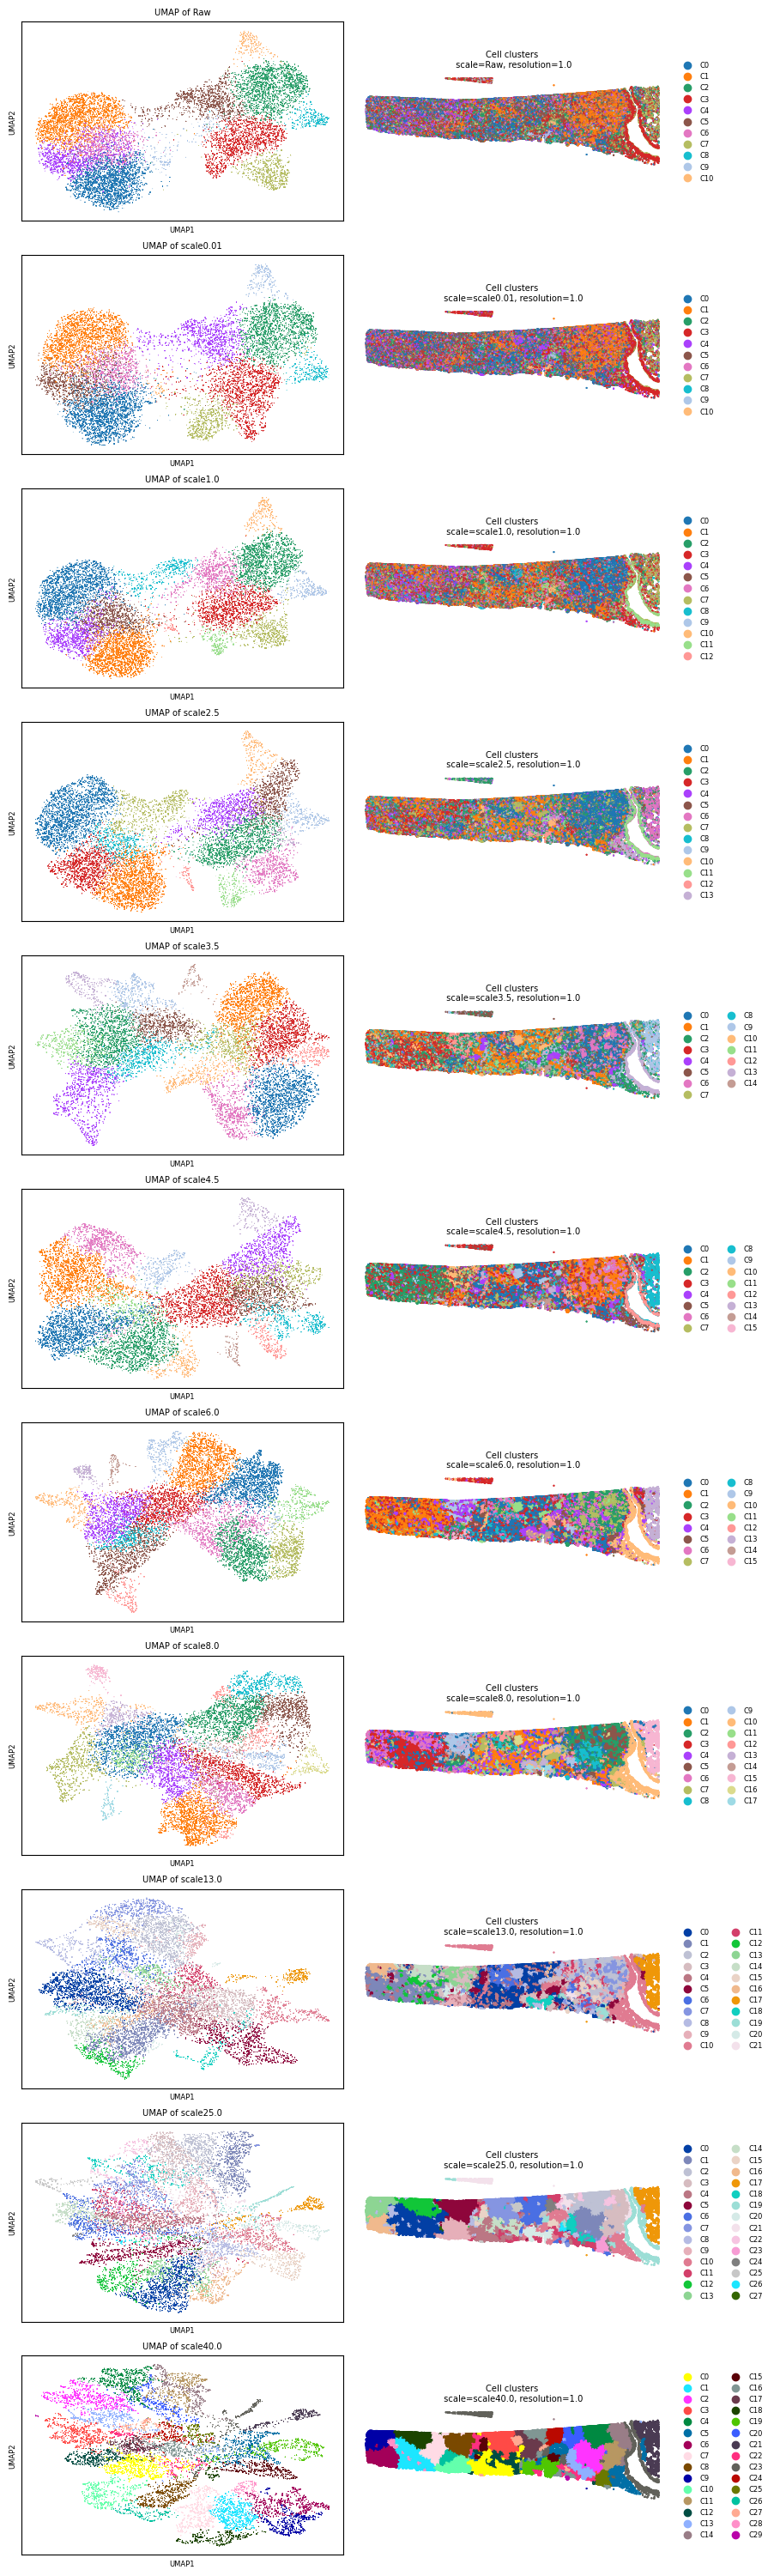

In [ ]:
sz_analyzer.plot_multiscale_clusters(resolution=1.0)

Quantify the contributions of spatial proximity and transcriptomic similarity to clustering outcomes across different scales:

Median similarities:  1018.6023184770336
time taken to construct expr_knn: 11.1874 seconds


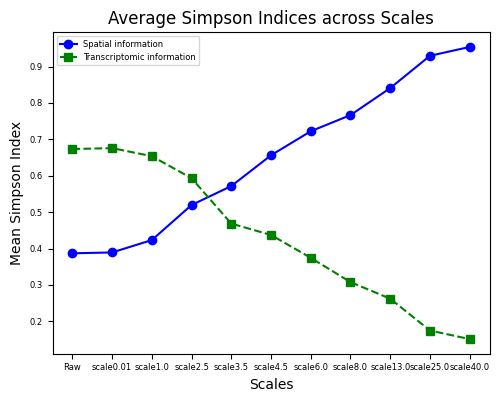

In [11]:
sz_analyzer.plot_simpson()

### 2.7 Inspect and Save Results

The clustering and UMAP results at each critical scale are stored in `sz_analyzer.adata`:

- **Clustering results** in `adata.obs`, with keys formatted as `leiden_<scale>_res<resolution>` (e.g., `leiden_Raw_res1`, `leiden_scale1.0_res1.0`).
- **UMAP embeddings** in `adata.obsm`, with keys formatted as `X_umap_<scale>` (e.g., `X_umap_Raw`, `X_umap_scale1.0`).

The `sz_analyzer.adata` object is a standard AnnData instance, compatible with **scanpy**, **squidpy**, and other Python tools for downstream analysis.

In [12]:
sz_analyzer.adata

AnnData object with n_obs × n_vars = 158615 × 377
    obs: 'nr_feats', 'perc_feats', 'total_expr', 'area', 'leiden_clus', 'Kmeans_Raw', 'leiden_Raw_res1.0', 'Kmeans_scale0.01', 'leiden_scale0.01_res1.0', 'Kmeans_scale1.0', 'leiden_scale1.0_res1.0', 'Kmeans_scale2.5', 'leiden_scale2.5_res1.0', 'Kmeans_scale3.5', 'leiden_scale3.5_res1.0', 'Kmeans_scale4.5', 'leiden_scale4.5_res1.0', 'Kmeans_scale6.0', 'leiden_scale6.0_res1.0', 'Kmeans_scale8.0', 'leiden_scale8.0_res1.0', 'Kmeans_scale13.0', 'leiden_scale13.0_res1.0', 'Kmeans_scale25.0', 'leiden_scale25.0_res1.0', 'Kmeans_scale40.0', 'leiden_scale40.0_res1.0'
    var: 'ensembl', 'type', 'nr_cells', 'perc_cells', 'total_expr', 'mean_expr', 'mean_expr_det', 'highly_variable'
    uns: 'pca', 'log1p', 'leiden_Raw_res1.0_colors', 'leiden_scale0.01_res1.0_colors', 'leiden_scale1.0_res1.0_colors', 'leiden_scale2.5_res1.0_colors', 'leiden_scale3.5_res1.0_colors', 'leiden_scale4.5_res1.0_colors', 'leiden_scale6.0_res1.0_colors', 'leiden_scale8.0_r

In [13]:
sz_analyzer.adata.write(save_path + runLabel + '_SpatialZoomer.h5ad')

### Output Files

The following files are generated in the `save_path` directory:

| File | Description |
|------|-------------|
| `<runLabel>_transformed_signals.h5` | Multi-scale features (cells × cell programs × candidate scales) |
| `Typical_scales.pdf` | Visualization of critical scale selection |
| `Typical_scales.csv` | Selected critical scales |
| `<runLabel>_object_kmeans_<scale>.h5ad` | K-Means metacell results at each critical scale |
| `Average_Simpson_Indices_across_Scales.pdf` | Simpson index plot across scales |
| `<runLabel>_SpatialZoomer.h5ad` | Final AnnData object with all multi-scale clustering results |